In [1]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['image.origin'] = 'lower'

In [2]:
import astropy.io.fits as fits
import numpy as np
import scipy.ndimage as ndimage

In [3]:
rng = np.random.default_rng(42)
nz, ny, nx = 128, 32, 32

flat = ndimage.gaussian_filter(rng.normal(1.0, 1e-2, size=(ny, nx)), sigma=1.0)
const = ndimage.zoom(rng.normal(40000, 100, size=(8, 8)), 4)
flux = ndimage.gaussian_filter1d(rng.normal(30000.0, 1000.0, size=(nz, 1, 1)), sigma=8, axis=0)

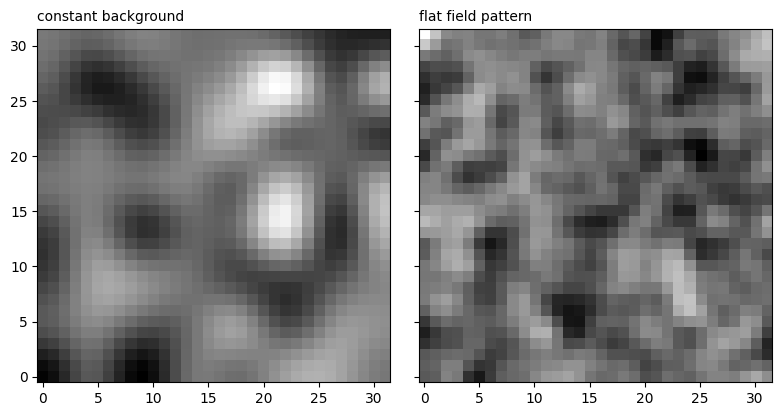

In [4]:
fig, axes = plt.subplots(
    1, 2, figsize=(8, 4), sharex=True, sharey=True)

axes[0].imshow(const, cmap='gray')
axes[0].set_title('constant background', fontsize=10, loc='left')

axes[1].imshow(flat, cmap='gray')
axes[1].set_title('flat field pattern', fontsize=10, loc='left')

fig.tight_layout()
plt.show()

In [5]:
one = np.zeros((ny, nx))
one[15, 15] = 1.0
star = ndimage.gaussian_filter(one, sigma=1.5)

def offset(x, y):
    dx = 16.0 - x
    dy = 16.0 - y
    return ndimage.affine_transform(star, np.eye(2), offset=(dy, dx))

In [6]:
rng = np.random.default_rng(1)
data = np.zeros((nz, ny, nx))
signal = 1000.0
pscale = 1000.0
x = 5.0 + 20.0 * np.linspace(0, 1, nz)
y = 20.0 - 3.0 * np.linspace(0, 1, nz)

poisson = lambda x: rng.poisson(pscale * x) / pscale

for n in range(nz):
    data[n] = poisson(const) + flat * poisson(flux[n] + signal * offset(x[n], y[n]))

data = np.array(data)

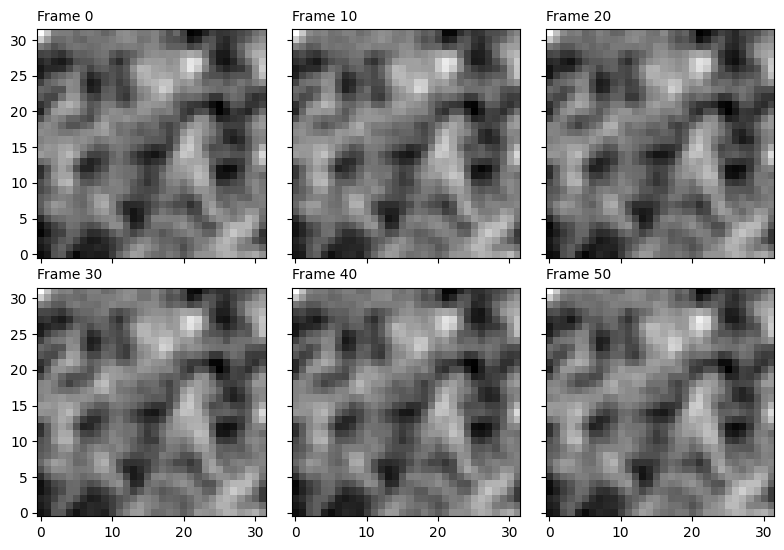

In [7]:
fig, axes = plt.subplots(
    2, 3, figsize=(8, 5.5), sharex=True, sharey=True)

for n, ax in enumerate(axes.flatten()):
    ax.imshow(data[n * 10], cmap='gray')
    ax.set_title(f'Frame {n * 10}', fontsize=10, loc='left')

fig.tight_layout()
plt.show()

In [8]:
header = fits.Header()

header['SEED'] = 42

phdu = fits.PrimaryHDU(data=data, header=header)
fhdu = fits.ImageHDU(data=flat, name='FLAT')
chdu = fits.ImageHDU(data=const, name='CONST')

hdul = fits.HDUList([phdu, fhdu, chdu])
hdul.info()

Filename: (No file associated with this HDUList)
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       8   (32, 32, 128)   float64   
  1  FLAT          1 ImageHDU         8   (32, 32)   float64   
  2  CONST         1 ImageHDU         8   (32, 32)   float64   


In [9]:
hdul.writeto('../data/demo.fits', overwrite=True)